In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.graphics.factorplots import interaction_plot
import scipy.stats as stats
from bioinfokit.analys import stat

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Gene of interest
goi = "GOI"
# Reference genes (list)
ref_list = ["UBQ", "ACT"]
# Control sample
ctlName = "Control"

In [3]:
#df = pd.read_csv("exp.csv", header=0)
df = pd.read_csv("exp_simulated_with_bioreps.csv", header=0)

In [4]:
# Mean Cq of each sample
mdf = df.groupby(["Target", "Sample", "Batch", "Replicate"], as_index=False).mean().rename({"Cq": "MCq"}, axis=1)

# Mean Cq of each biological group
mmdf = mdf.groupby(["Target", "Sample"], as_index = False).MCq.mean()

ctlMCq = list(mmdf[mmdf.Sample==ctlName].MCq)

# Relative Quantity (in biological group)
mmdf["RQ"] = [2 ** (ctlMCq[int(i // (len(mmdf) / len(ctlMCq)))] - mmdf.MCq[i]) for i in range(len(mmdf))]

# Normalized Expression of Relative Quantity (in biological group)
dfgoi = mmdf[mmdf.Target==goi].copy().reset_index(drop=True)
# Calculate geometric mean of reference genes RQ
rq_ref_geomean_list = []
for sample_idx in range(len(mmdf[mmdf.Target==ref_list[0]])):
    rq_values = [mmdf[mmdf.Target==ref].reset_index(drop=True).RQ[sample_idx] for ref in ref_list]
    geomean = math.prod(rq_values) ** (1 / len(rq_values))
    rq_ref_geomean_list.append(geomean)
dfgoi["NE"] = list(mmdf[mmdf.Target==goi].RQ.values / np.array(rq_ref_geomean_list))

# Relative Quantity of each sample for each reference gene and GOI
RQ_refs = {}
for ref_gene in ref_list:
    RQ_refs[ref_gene] = [2 ** (ctlMCq[ref_list.index(ref_gene)]-mdf[mdf.Target==ref_gene].reset_index(drop=True).MCq[i]) for i in range(len(mdf[mdf.Target==ref_gene]))]

RQ_goi = [2 ** (ctlMCq[len(ref_list)]-mdf[mdf.Target==goi].reset_index(drop=True).MCq[i]) for i in range(len(mdf[mdf.Target==goi]))]

# Normalized Expression of each sample (using geometric mean of reference genes)
RNEgoi = []
for i in range(len(RQ_goi)):
    rq_ref_values = [RQ_refs[ref_gene][i] for ref_gene in ref_list]
    rq_ref_geomean = math.prod(rq_ref_values) ** (1 / len(rq_ref_values))
    RNEgoi.append(RQ_goi[i] / rq_ref_geomean)

## Gene Expression Data Table - Verbose

In [5]:
mdfgoi = mdf[mdf.Target==goi].copy().reset_index(drop=True)
mdfgoi["RNE"] = RNEgoi
mdfgoi["RNE_lg"] = [math.log(e, 2) for e in RNEgoi]
mdfgoi

,Target,Sample,Batch,Replicate,MCq,RNE,RNE_lg
0,GOI,Control,Batch1,1,18.703656,4.765303e-07,-21.000929
1,GOI,Control,Batch1,2,18.686030,4.179816e-07,-21.190057
2,GOI,Control,Batch1,3,18.659978,4.685455e-07,-21.025307
3,GOI,Control,Batch2,1,21.900520,8.869232e-07,-20.104688
4,GOI,Control,Batch2,2,21.713884,9.735719e-07,-19.970209
5,GOI,Control,Batch2,3,22.016550,9.313375e-07,-20.034193
6,GOI,Control,Batch3,1,26.001237,1.041575e-06,-19.872802
7,GOI,Control,Batch3,2,26.025728,1.075844e-06,-19.826100
8,GOI,Control,Batch3,3,25.999967,1.026173e-06,-19.894295
9,GOI,Treatment_A,Batch1,1,18.327670,7.275109e-07,-20.390528


## Gene Expression Data Table

In [6]:
dfgoi["SEM_lg"] = mdfgoi.groupby(["Target", "Sample"], as_index=False).RNE_lg.sem().RNE_lg
dfgoi

,Target,Sample,MCq,RQ,NE,SEM_lg
0,GOI,Control,22.189728,1.000000,1.000000,0.189792
1,GOI,Treatment_A,22.456040,0.831442,0.949498,0.071187
2,GOI,Treatment_B,21.886205,1.234154,1.566632,0.142550
3,GOI,Treatment_C,21.775405,1.332673,1.590525,0.113264


## Bar Chart w/ SEM

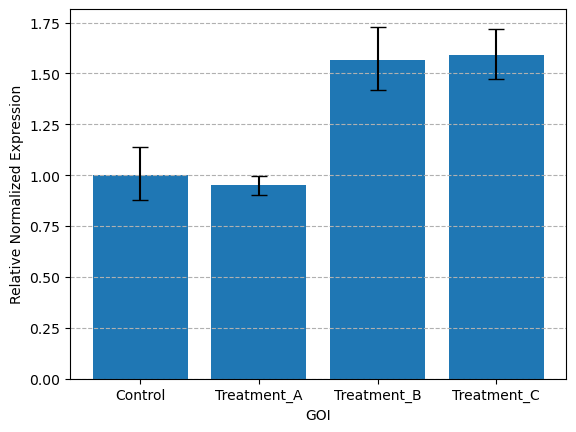

In [7]:
ue = [2 ** (math.log(dfgoi.NE[i], 2) + dfgoi.SEM_lg[i]) - dfgoi.NE[i] for i in range(len(dfgoi))]
le = [dfgoi.NE[i] - 2 ** (math.log(dfgoi.NE[i], 2) - dfgoi.SEM_lg[i]) for i in range(len(dfgoi))]

x = np.arange(len(dfgoi))
plt.bar(x, dfgoi.NE, yerr=[le, ue], capsize=6)
plt.grid(axis="y", linestyle="--")
plt.xticks(x, dfgoi.Sample)
plt.xlabel(goi)
plt.ylabel("Relative Normalized Expression")
plt.show()

## Boxplot w/ Scatter

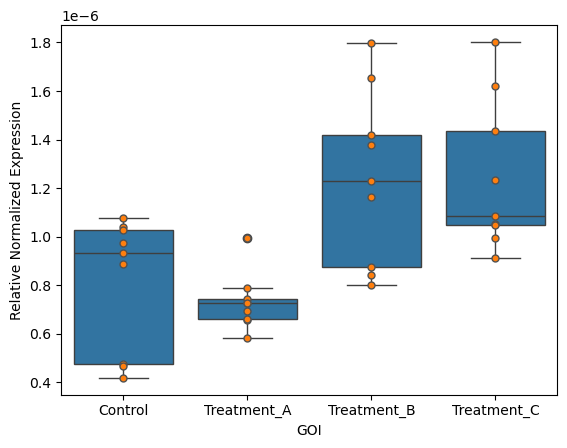

In [8]:
ax = sns.boxplot(data=mdfgoi, x="Sample", y="RNE", boxprops={"alpha": 1})
sns.stripplot(data=mdfgoi, x="Sample", y="RNE",linewidth=1, jitter=False, ax=ax)
plt.xlabel(goi)
plt.ylabel("Relative Normalized Expression")
plt.show()

In [9]:
# Batch (block) and Replicate as int may cause wrong df
mdfgoi.Batch = mdfgoi.Batch.apply(str)
mdfgoi.Replicate = mdfgoi.Replicate.apply(str)

In [10]:
mdfgoi.pivot(index="Sample", columns=["Batch", "Replicate"], values="RNE_lg")

Batch           Batch1                           Batch2                        \
Replicate            1          2          3          1          2          3   
Sample                                                                          
Control     -21.000929 -21.190057 -21.025307 -20.104688 -19.970209 -20.034193   
Treatment_A -20.390528 -20.706238 -20.539825 -19.938699 -20.362007 -20.272074   
Treatment_B -20.179700 -20.122617 -20.251786 -19.207217 -19.470336 -19.084013   
Treatment_C -19.859039 -19.812641 -19.862879 -19.234423 -19.410669 -19.081707   

Batch           Batch3                        
Replicate            1          2          3  
Sample                                        
Control     -19.872802 -19.826100 -19.894295  
Treatment_A -20.459682 -20.531182 -20.391206  
Treatment_B -19.634178 -19.714080 -19.425658  
Treatment_C -20.064795 -19.938032 -19.628870

## SET BATCH AS BLOCK EFFECT (RCBD)
## With subsampling
### Two-Way ANOVA wo/ interaction


In [11]:
res = stat()
m_formula = "RNE_lg ~ C(Sample) + C(Batch)"
res.anova_stat(df=mdfgoi, res_var="RNE_lg", anova_model=m_formula)
res.anova_summary

,df,sum_sq,mean_sq,F,PR(>F)
C(Sample),3.0,4.386611,1.462204,21.265798,1.404875e-07
C(Batch),2.0,3.282366,1.641183,23.868812,6.271188e-07
Residual,30.0,2.062754,0.068758,NaN,NaN


### Post-hoc analyses

In [12]:
# Tukey HSD
res = stat()
# for main effect Sample
res.tukey_hsd(df=mdfgoi, res_var="RNE_lg", xfac_var="Sample", anova_model=m_formula)
res.tukey_summary

/lib/python3.11/site-packages/bioinfokit/analys.py:431: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  mult_group[ele] = df[df[xfac_var] == ele].mean().loc[res_var]
/lib/python3.11/site-packages/bioinfokit/analys.py:431: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  mult_group[ele] = df[df[xfac_var] == ele].mean().loc[res_var]
/lib/python3.11/site-packages/bioinfokit/analys.py:431: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying

,group1,group2,Diff,Lower,Upper,q-value,p-value
0,Control,Treatment_A,0.074763,-0.261337,0.410862,0.855347,0.900
1,Control,Treatment_B,0.647666,0.311566,0.983766,7.409847,0.001
2,Control,Treatment_C,0.669503,0.333403,1.005602,7.659677,0.001
3,Treatment_A,Treatment_B,0.722429,0.386329,1.058528,8.265194,0.001
4,Treatment_A,Treatment_C,0.744265,0.408166,1.080365,8.515024,0.001
5,Treatment_B,Treatment_C,0.021837,-0.314263,0.357936,0.249830,0.900


In [13]:
# for block effect Batch
res.tukey_hsd(df=mdfgoi, res_var="RNE_lg", xfac_var="Batch", anova_model=m_formula)
res.tukey_summary

/lib/python3.11/site-packages/bioinfokit/analys.py:431: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  mult_group[ele] = df[df[xfac_var] == ele].mean().loc[res_var]
/lib/python3.11/site-packages/bioinfokit/analys.py:431: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  mult_group[ele] = df[df[xfac_var] == ele].mean().loc[res_var]
/lib/python3.11/site-packages/bioinfokit/analys.py:431: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying

,group1,group2,Diff,Lower,Upper,q-value,p-value
0,Batch1,Batch2,0.730943,0.467092,0.994794,9.656302,0.001000
1,Batch1,Batch3,0.463389,0.199538,0.727240,6.121715,0.001000
2,Batch2,Batch3,0.267554,0.003703,0.531405,3.534587,0.046349


## Interaction plot

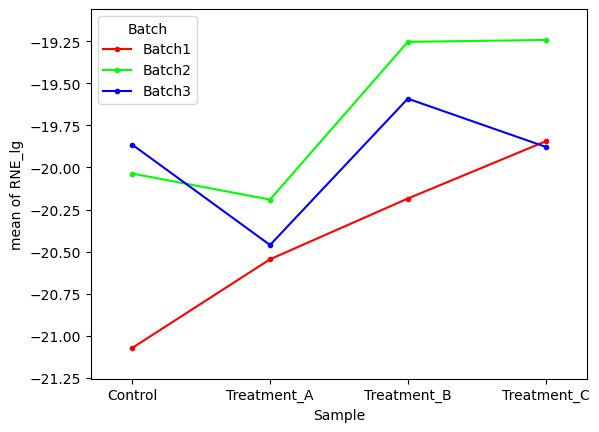

In [14]:
# Interaction plot
fig = interaction_plot(x=mdfgoi["Sample"], trace=mdfgoi["Batch"], response=mdfgoi["RNE_lg"])
plt.show()

### Test ANOVA assumptions

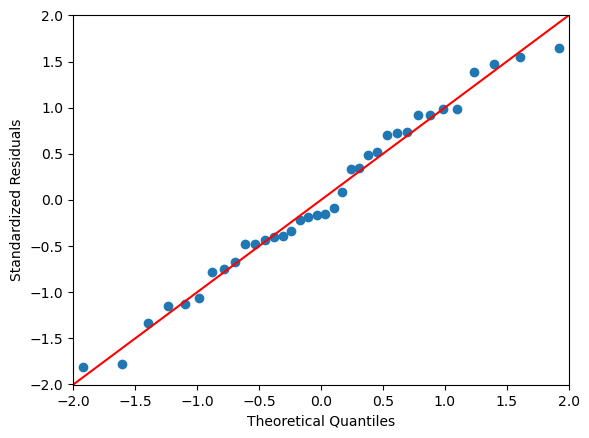

In [15]:
# res.anova_std_residuals are standardized residuals obtained from ANOVA (check above)
sm.qqplot(res.anova_std_residuals, line="45")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Standardized Residuals")
plt.show()

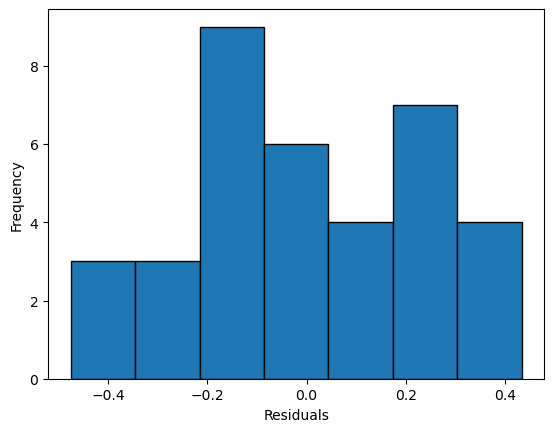

In [16]:
# histogram
plt.hist(res.anova_model_out.resid, bins="auto", histtype="bar", ec="k") 
plt.xlabel("Residuals")
plt.ylabel('Frequency')
plt.show()

In [17]:
# Shapiro-Wilk test - normal distribution of residuals
## H0: data is drawn from normal distribution
model = ols(m_formula, data=mdfgoi).fit()
w, pvalue = stats.shapiro(model.resid)
print(w, pvalue)

0.9740601181983948 0.5462989807128906


In [18]:
# Bartlett’s test - homogeneity of variances when the data is drawn from normal distribution
## H0: samples from populations have equal variances
res = stat()
res.bartlett(df=mdfgoi, res_var="RNE_lg", xfac_var="Sample")
res.bartlett_summary

,Parameter,Value
0,Test statistics (T),6.9472
1,Degrees of freedom (Df),3.0000
2,p value,0.0736


In [19]:
# Levene’s test - homogeneity of variances when the data is not drawn from normal distribution
## H0: samples from populations have equal variances
res = stat()
res.levene(df=mdfgoi, res_var="RNE_lg", xfac_var="Sample")
res.levene_summary

,Parameter,Value
0,Test statistics (W),1.3746
1,Degrees of freedom (Df),3.0000
2,p value,0.2682


### Efficiency of blocking

In [20]:
# If there is no treatment effect, then F = MSB/MSE
# If F = 1, blocking is irrelevant to the result
# If F < 1, blocking is misplaced and therefore jeopardizes the result
# If F > 1, blocking is beneficial to the result
m_formula = "RNE_lg ~ C(Batch)"
res.anova_stat(df=mdfgoi, res_var="RNE_lg", anova_model=m_formula)
res.anova_summary

,df,sum_sq,mean_sq,F,PR(>F)
C(Batch),2.0,3.282366,1.641183,8.397576,0.001127
Residual,33.0,6.449365,0.195435,NaN,NaN
